# Get to coding

## Cell 1 - Config

Defining EPOCHS, BATCH_SIZE, VAL_SPLIT and N_SAMPLES

In [1]:
EPOCHS = 15
BATCH_SIZE = 64
VAL_SPLIT = 0.2
N_SAMPLES = 10_000

## Cell 2 - Vocabulary Manifest

Setting the preferences for `strArea` and `strCategory` to match the ones available in `account.tsx`.

In [2]:
# TheMealDB canonical strArea values
AREAS = [
    "American", "British", "Canadian", "Chinese", "Croatian",
    "Dutch", "Egyptian", "Filipino", "French", "Greek",
    "Indian", "Irish", "Italian", "Jamaican", "Japanese",
    "Kenyan", "Malaysian", "Mexican", "Moroccan", "Polish",
    "Portuguese", "Russian", "Spanish", "Thai", "Tunisian",
    "Turkish", "Ukrainian", "Unknown", "Vietnamese",
]

# TheMealDB canonical strCategory values
CATEGORIES = [
    "Beef", "Breakfast", "Chicken", "Dessert", "Goat",
    "Lamb", "Miscellaneous", "Pasta", "Pork", "Seafood",
    "Side", "Starter", "Vegan", "Vegetarian",
]

N_AREAS = len(AREAS)          # 29
N_CATEGORIES = len(CATEGORIES) # 14
print(f"Areas: {N_AREAS}, Categories: {N_CATEGORIES}")

Areas: 29, Categories: 14


## Cell 3 - Training Data Generation

Simulate random recipe+user_prefs pairs and label them based on match score.

In [3]:
import numpy as np

rng = np.random.default_rng(42)

def generate_sample():
    # Simulate a recipe: one area, one category
    recipe_area_idx = rng.integers(0, N_AREAS)
    recipe_cat_idx  = rng.integers(0, N_CATEGORIES)

    # Simulate user preferences: 0–5 areas, 0–5 categories
    n_user_areas = rng.integers(0, 6)
    n_user_cats  = rng.integers(0, 6)
    user_areas   = set(rng.choice(N_AREAS, n_user_areas, replace=False).tolist())
    user_cats    = set(rng.choice(N_CATEGORIES, n_user_cats, replace=False).tolist())

    # Binary match signals
    area_match = 1.0 if recipe_area_idx in user_areas else 0.0
    cat_match  = 1.0 if recipe_cat_idx  in user_cats  else 0.0

    x = np.array([area_match, cat_match, area_match, cat_match], dtype=np.float32)

    # Weighted Regression Label
    # Category = 0.6, Area = 0.4
    y = (cat_match * 0.6) + (area_match * 0.4)

    return x, y


samples = [generate_sample() for _ in range(N_SAMPLES)]
X_train = np.stack([s[0] for s in samples])
y_train = np.array([s[1] for s in samples], dtype=np.float32)

print(f"X_train shape: {X_train.shape}")
print(f"Label distribution: 0.0={float((y_train==0).mean()):.2f},
0.5={float((y_train==0.5).mean()):.2f}, 1.0={float((y_train==1.0).mean()):.2f}")


X_train shape: (10000, 4)
Label distribution: 0.0=0.75, 0.5=0.00, 1.0=0.01


## Cell 4 - Class Balance Check

Show how many entries of which score is generated

In [4]:
from collections import Counter

# For regression labels, show value distribution
unique, cnts = np.unique(y_train, return_counts=True)
print("Label value counts:")
for v, c in zip(unique, cnts):
    print(f"With the score of {v:.1f}, there are {c} labels. ({100*c/len(y_train):.1f}%)")


Label value counts:
  0.0: 7513 (75.1%)
  0.4: 706 (7.1%)
  0.6: 1634 (16.3%)
  1.0: 147 (1.5%)


## Cell 5 - Model Architecture

The model consists of 4 inputs, 8 hidden ReLU layers and 1 sigmoid output layer.
Total parameters: (4×8 + 8) + (8×1 + 1) = **49 weights**. This equals to TFJS shards of size 5 KB each.

In [5]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

model = tf.keras.Sequential([
    layers.Dense(8, activation="relu", input_shape=(4,)), # 8 hidden ReLU layers and 4 inputs
    # Use sigmoid to ensure the output is always a valid 0-1 percentage
    layers.Dense(1, activation="sigmoid"), 
], name="preference_regressor")

model.compile(
    optimizer="adam",
    loss="mse",       # Mean Squared Error for regression
    metrics=["mae"]   # Mean Absolute Error to see average % deviation
)

model.summary()


/home/bram/.local/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "preference_regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49 (196.00 B)

 Trainable params: 49 (196.00 B)

 Non-trainable params: 0 (0.00 B)

## Cell 6 - Training

In [6]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
)

history = model.fit(
    X_train,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VAL_SPLIT,
    callbacks=[early_stopping],
)

print(f"Final val_loss: {min(history.history['val_loss']):.4f}")
print(f"Final val_mae:  {min(history.history['val_mae']):.4f}")


Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1729 - mae: 0.3792 - val_loss: 0.1437 - val_mae: 0.3424
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 811us/step - loss: 0.1166 - mae: 0.3034 - val_loss: 0.0919 - val_mae: 0.2666
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 784us/step - loss: 0.0716 - mae: 0.2343 - val_loss: 0.0541 - val_mae: 0.2053
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 797us/step - loss: 0.0417 - mae: 0.1790 - val_loss: 0.0314 - val_mae: 0.1561
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 777us/step - loss: 0.0246 - mae: 0.1372 - val_loss: 0.0190 - val_mae: 0.1209
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 767us/step - loss: 0.0153 - mae: 0.1079 - val_loss: 0.0122 - val_mae: 0.0967
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 776us/step - loss: 0.0101 - mae: 0.0876 - val_loss: 0.0083 - val_mae: 0.0797
Epoch 8/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 768us/step - loss: 0.0070 - mae: 0.0730 - val_loss: 0.0059 - val_mae: 0.0673
Epoch 9/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s

## Cell 7 - Smoke Tests

Verifying that the model has learned correctly. Outputs match type, expected score and actual score.

In [7]:
test_cases = [
    ([1.0, 1.0, 1.0, 1.0], "Both match: Expected score ~1.0"),
    ([1.0, 0.0, 1.0, 0.0], "Area only match: Expected score ~0.5"),
    ([0.0, 1.0, 0.0, 1.0], "Category only match: Expected score ~0.5"),
    ([0.0, 0.0, 0.0, 0.0], "No match at all: Expected score ~0.0"),
]

for x_vals, label in test_cases:
    x = np.array([x_vals], dtype=np.float32)
    score = float(np.clip(model.predict(x, verbose=0)[0][0], 0.0, 1.0))
    print(f"{label}. Actual score = {score:.3f}")



Both match: Expected score ~1.0. Actual score = 0.983
Area only match: Expected score ~0.5. Actual score = 0.400
Category only match: Expected score ~0.5. Actual score = 0.600
No match at all: Expected score ~0.0. Actual score = 0.040


## Cell 8 - Save Keras Model

In [8]:
model.save("preference_mlp_regr.keras")
print("Saved: preference_mlp_regr.keras")

Saved: preference_mlp_regr.keras


## Cell 9 - Produce graphs

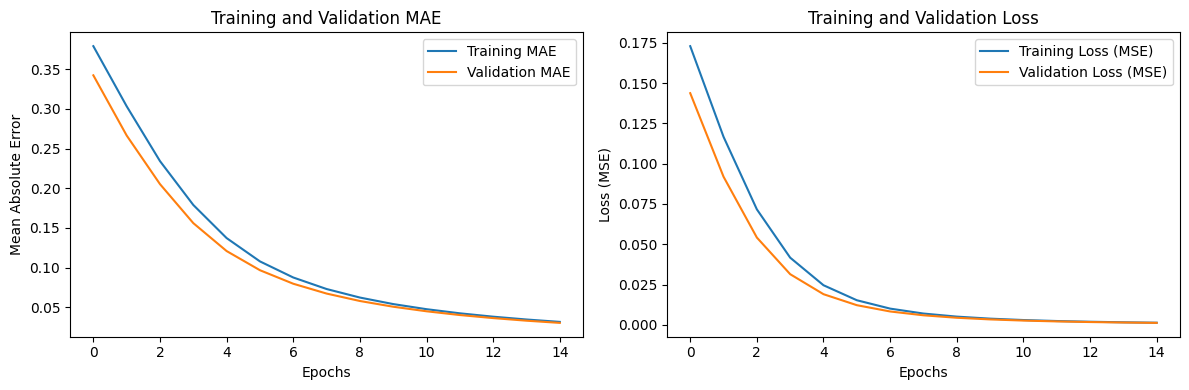

Final Training MAE: 0.0316
Final Validation MAE: 0.0304


In [10]:
import matplotlib.pyplot as plt

# Extract data from the history object
mae = history.history['mae']
val_mae = history.history['val_mae']

loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot the training and validation MAE
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(mae, label='Training MAE')
plt.plot(val_mae, label='Validation MAE')
plt.legend(loc='upper right')
plt.title('Training and Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')

# Plot the training and validation loss
plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss (MSE)')
plt.plot(val_loss, label='Validation Loss (MSE)')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')

plt.tight_layout()
plt.show()

print(f"Final Training MAE: {mae[-1]:.4f}")
print(f"Final Validation MAE: {val_mae[-1]:.4f}")

## Cell 9 - Convert to TFJS

Produces `./tfjs_preference_mlp/model.json` and a single small `.bin` weight shard.  
This is then copied into `SpisNemt_FE/src/ml/MLP/`.

In [9]:
import tensorflowjs as tfjs
import os

# Create the output directory if it doesn't exist
output_path = './tmp/mlp'
if not os.path.exists(output_path):
    os.makedirs(output_path)

# Convert the model directly from the memory object
# This avoids the "InputLayer" deserialization bug in the CLI
tfjs.converters.save_keras_model(model, output_path)

print(f"Conversion complete. Files in {output_path}:")
!ls -lh {output_path}

/home/bram/.local/lib/python3.11/site-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


failed to lookup keras version from the file,
    this is likely a weight only file
Conversion complete. Files in ./tmp/mlp:
total 7.0K
-rw-r--r-- 1 bram gpuusers  196 May 27 20:12 group1-shard1of1.bin
-rw-r--r-- 1 bram gpuusers 2.8K May 27 20:12 model.json
-rw-r--r-- 1 bram gpuusers  22K Apr  2 15:17 preference_mlp.keras


## Cell 10 — Next Steps

After the converter runs:

1. Copy `./tfjs_preference_mlp/model.json` and `./tfjs_preference_mlp/group1-shard1of1.bin` into `SpisNemt_FE/src/ml/MLP/`
2. The TypeScript service at `SpisNemt_FE/src/services/ml/preferencesMatcher.ts` will load them via `bundleResourceIO`
3. No code changes needed — asset paths are already wired up